Aluno: Lucas Barbosa dos Santos

In [1]:
!pip install tsai

In [2]:
from tsai.all import *
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print(regression_datasets)

['AppliancesEnergy', 'AustraliaRainfall', 'BeijingPM10Quality', 'BeijingPM25Quality', 'BenzeneConcentration', 'Covid3Month', 'FloodModeling1', 'FloodModeling2', 'FloodModeling3', 'HouseholdPowerConsumption1', 'HouseholdPowerConsumption2', 'IEEEPPG', 'LiveFuelMoistureContent', 'NewsHeadlineSentiment', 'NewsTitleSentiment']


In [17]:
def get_regression_dataid(dsid: str = "Covid3Month"):
  X, y, splits = get_regression_data(dsid, split_data=False)
  return X, y, splits

In [18]:
X, y, splits = get_regression_dataid()

153it [00:00, 6470.86it/s]
74it [00:00, 7104.76it/s]


X      - shape: [201 samples x 1 features x 84 timesteps]  type: memmap  dtype:float64  isnan: 0
y      - shape: (201,)  type: memmap  dtype:float64  isnan: 0
splits - n_splits: 2 shape: [140, 61]  overlap: False


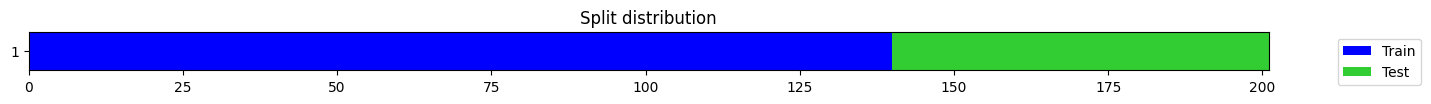

In [19]:
check_data(X, y, splits)

In [20]:
tfms  = [None, [TSRegression()]]
batch_tfms = TSStandardize(by_sample=True, by_var=True)
dls = get_ts_dls(X, y, splits=splits, tfms=tfms, batch_tfms=batch_tfms, bs=32)

In [21]:
dls.one_batch()

(TSTensor(samples:32, vars:1, len:84, device=cpu, dtype=torch.float32),
 tensor([0.0405, 0.0000, 0.0347, 0.0556, 0.0000, 0.0000, 0.0000, 0.0160, 0.0146,
         0.0125, 0.0563, 0.0445, 0.1111, 0.1111, 0.0212, 0.0210, 0.0776, 0.0081,
         0.0000, 0.0076, 0.0289, 0.0000, 0.0069, 0.0321, 0.1702, 0.0000, 0.0236,
         0.0000, 0.0116, 0.0176, 0.0000, 0.0000]))

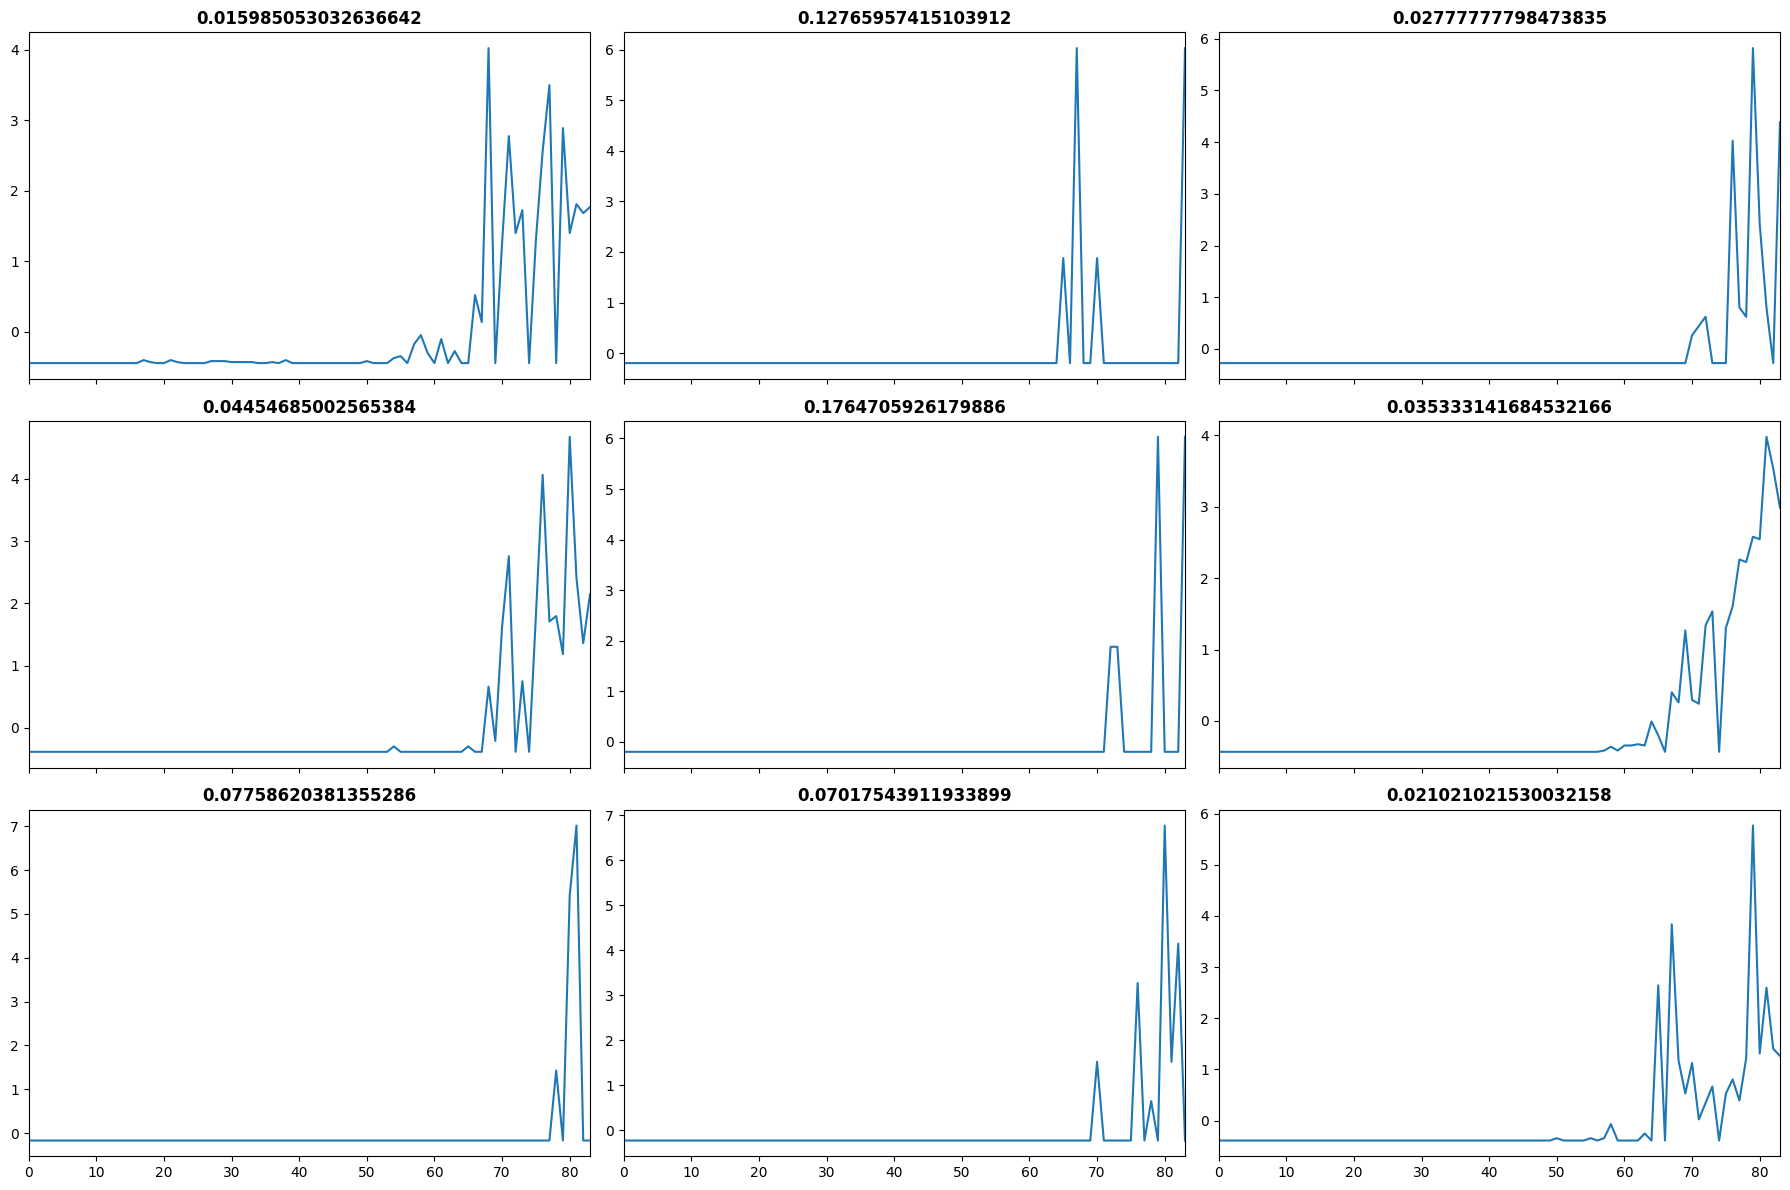

In [22]:
dls.show_batch()

SuggestedLRs(valley=0.0030199517495930195)

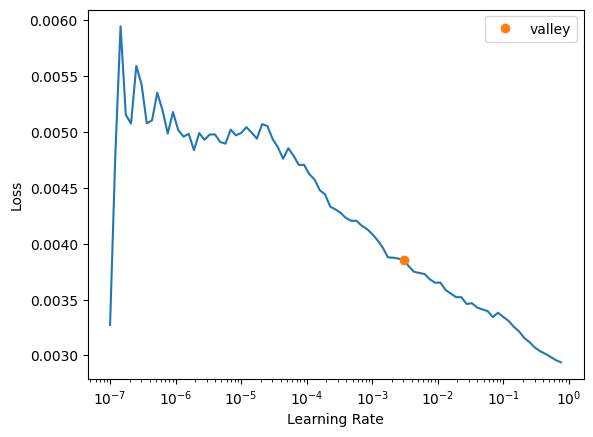

In [26]:
learn = ts_learner(dls, LSTM, metrics=[mae, rmse], cbs=ShowGraph())
learn.lr_find()

In [24]:
learn.loss_func

FlattenedLoss of MSELoss()

epoch,train_loss,valid_loss,mae,_rmse,time
0,0.006816,0.005061,0.055812,0.071144,00:00
1,0.006634,0.004266,0.051400,0.065314,00:00
2,0.006231,0.003576,0.045025,0.059798,00:00
3,0.005632,0.002611,0.036480,0.051096,00:00
4,0.004908,0.002194,0.031527,0.046838,00:00
5,0.004324,0.002159,0.033017,0.046467,00:00
6,0.003920,0.002227,0.037091,0.047189,00:00
7,0.003583,0.002149,0.031245,0.046353,00:00
8,0.003301,0.001895,0.032527,0.043535,00:00
9,0.003093,0.001883,0.030145,0.043392,00:00


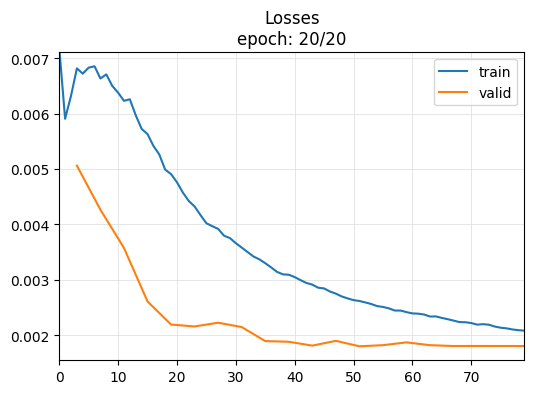

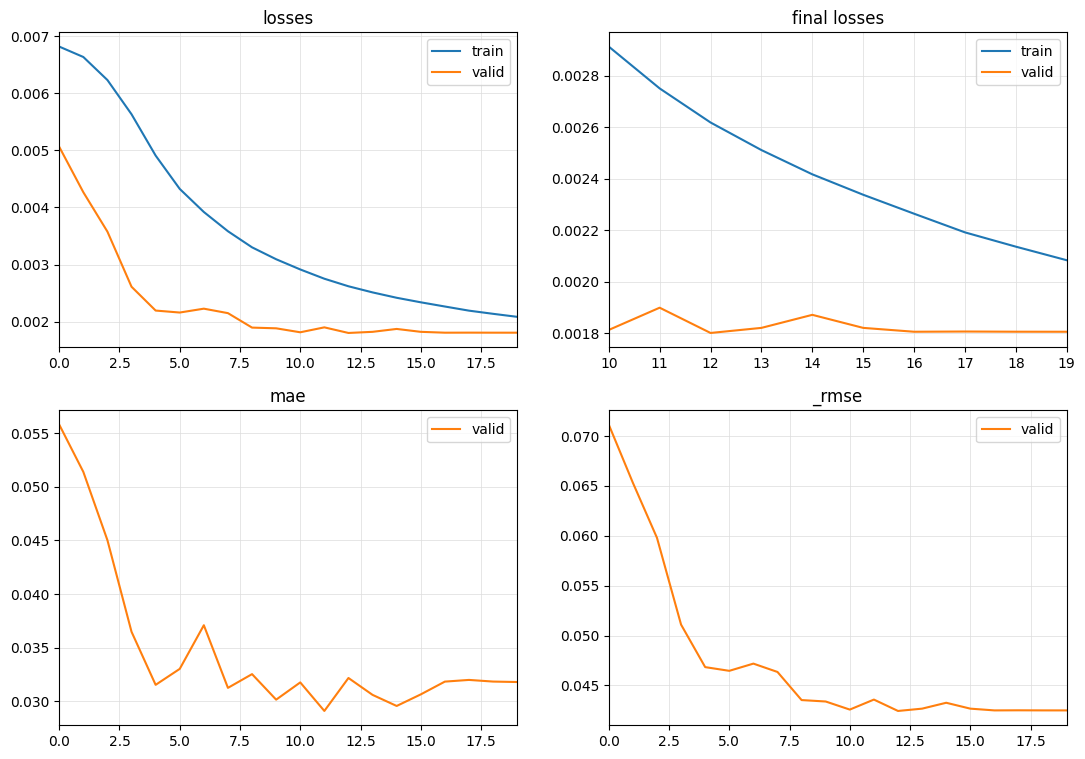

In [27]:
learn = ts_learner(dls, LSTM, metrics=[mae, rmse], cbs=ShowGraph())
learn.fit_one_cycle(20, 1e-3)